# Skin Cancer Risk Prediction Model
This notebook trains a machine learning model to predict skin cancer risk level (Low / Moderate / High) from a patient questionnaire.

In [43]:
# Step 1 — Install required libraries (run once if needed)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [44]:
# Step 2 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Libraries imported successfully.')

Libraries imported successfully.


In [45]:
# Step 3 — Load dataset
df = pd.read_csv('skin_cancer_questionnaire_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (2000, 33)

Columns: ['patient_id', 'age', 'sex', 'skin_tone', 'natural_hair_color', 'eye_color', 'freckles', 'number_of_moles', 'moles_larger_than_5mm', 'changing_mole_or_lesion', 'new_unusual_skin_growth', 'skin_easily_sunburned', 'tanning_ability', 'sunburns_in_childhood', 'severe_blistering_sunburns_ever', 'daily_sun_exposure_hours', 'outdoor_work_or_recreation', 'use_of_sunscreen', 'use_of_tanning_bed', 'years_of_tanning_bed_use', 'personal_history_skin_cancer', 'family_history_skin_cancer', 'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history', 'geographic_location_uv', 'years_lived_in_high_uv_area', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants', 'smoking_status', 'risk_level']

First 3 rows:


,patient_id,age,sex,skin_tone,natural_hair_color,eye_color,freckles,number_of_moles,moles_larger_than_5mm,changing_mole_or_lesion,...,autoimmune_disease,radiation_therapy_history,geographic_location_uv,years_lived_in_high_uv_area,protective_clothing_worn,perform_skin_self_checks,seen_dermatologist,diet_high_antioxidants,smoking_status,risk_level
0,SC0001,58,Male,Very Fair,Light Brown,Green,Few,11-25,NaN,No,...,No,No,High UV region,More than 15 years,Sometimes,Once a year,Once every few years,Rarely,Former,Low Risk
1,SC0002,40,Female,Brown,Light Brown,Blue,Many,More than 100,NaN,Yes,...,Yes,Yes,High UV region,5-15 years,Rarely,Once a year,Annually,Rarely,Current,Moderate Risk
2,SC0003,35,Male,Brown,Blonde,Dark Brown,Few,11-25,More than 5,Yes,...,No,Yes,Moderate UV region,More than 15 years,Rarely,Once a year,Once every few years,Rarely,Current,Moderate Risk


In [46]:
# Step 3b — Inspect actual unique values in ordinal columns (run this to fix encoding mismatches)
ordinal_cols_to_check = [
    'number_of_moles', 'tanning_ability', 'sunburns_in_childhood',
    'skin_easily_sunburned', 'daily_sun_exposure_hours',
    'years_of_tanning_bed_use', 'years_lived_in_high_uv_area',
    'geographic_location_uv'
]
for col in ordinal_cols_to_check:
    print(f'\n{col}:')
    print(sorted(df[col].dropna().unique().tolist()))


number_of_moles:
['0-10', '11-25', '26-50', '51-100', 'More than 100']

tanning_ability:
['Never tans', 'Rarely tans', 'Tans easily and deeply', 'Tans gradually']

sunburns_in_childhood:
['1-2', '3-5', 'More than 5']

skin_easily_sunburned:
['Always', 'Never', 'Often', 'Rarely', 'Sometimes']

daily_sun_exposure_hours:
['1-3 hours', '3-6 hours', 'Less than 1 hour', 'More than 6 hours']

years_of_tanning_bed_use:
['1-5 years', 'Less than 1 year', 'More than 5 years', 'Never used']

years_lived_in_high_uv_area:
['5-15 years', 'Less than 5 years', 'More than 15 years', 'Never']

geographic_location_uv:
['High UV region', 'Low UV region', 'Moderate UV region']


Target value counts:
risk_level
Low Risk         1000
Moderate Risk     600
High Risk         400
Name: count, dtype: int64


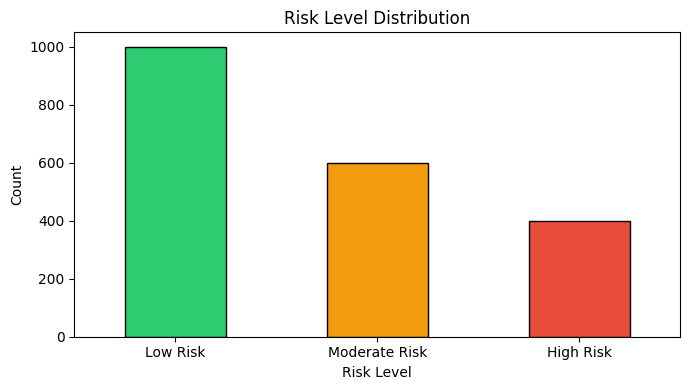

In [47]:
# Step 4 — Explore target distribution
print('Target value counts:')
print(df['risk_level'].value_counts())

df['risk_level'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='black', figsize=(7, 4)
)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# Step 5 — Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
freckles                      516
moles_larger_than_5mm         511
sunburns_in_childhood         491
family_history_skin_cancer    684
dtype: int64


In [49]:
# Step 7 — Define feature groups for encoding

# Numeric feature (no encoding needed)
numeric_features = ['age']

# Ordinal features — categories listed LOW -> HIGH risk order (actual values from dataset)
ordinal_features = {
    'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
    'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
    'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
    'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
    'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
    'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
    'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
    'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
    # Multi-level ordinal — actual CSV values are NOT Yes/No; moved out of binary group
    'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
    'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
    'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
    'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
    'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
    'protective_clothing_worn':    ['Always', 'Usually', 'Sometimes', 'Rarely', 'Never'],
    'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
    'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
    'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
}

# Binary Yes/No columns — only genuine Yes/No fields in the dataset
binary_yn_features = [
    'changing_mole_or_lesion', 'new_unusual_skin_growth',
    'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
    'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history',
]

# Nominal features — no natural order; one-hot encoded
nominal_features = ['sex', 'skin_tone', 'natural_hair_color', 'eye_color',
                    'use_of_sunscreen', 'smoking_status']

print('Feature groups defined.')
print(f'  Ordinal columns : {list(ordinal_features.keys())}')

Feature groups defined.
  Ordinal columns : ['skin_easily_sunburned', 'tanning_ability', 'daily_sun_exposure_hours', 'years_of_tanning_bed_use', 'years_lived_in_high_uv_area', 'number_of_moles', 'sunburns_in_childhood', 'geographic_location_uv', 'freckles', 'moles_larger_than_5mm', 'family_history_skin_cancer', 'outdoor_work_or_recreation', 'use_of_tanning_bed', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants']


In [50]:
# Step 8 — Encode features

df_enc = df.copy()

# Drop non-feature identifier column before encoding
df_enc = df_enc.drop(columns=['patient_id'])

# --- Ordinal encoding (preserves order) ---
for col, categories in ordinal_features.items():
    enc = OrdinalEncoder(
        categories=[categories],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    df_enc[col] = enc.fit_transform(df_enc[[col]])

# Replace -1 (unknown sentinel) with 0 (lowest category) so no negatives reach the model
for col in ordinal_features.keys():
    df_enc[col] = df_enc[col].clip(lower=0)

# --- Binary Yes/No -> 1/0 ---
for col in binary_yn_features:
    df_enc[col] = df_enc[col].apply(
        lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
    )

# --- Nominal -> one-hot ---
df_enc = pd.get_dummies(df_enc, columns=nominal_features, drop_first=False)

# Force any bool columns (pandas 2.0+) to float
bool_cols = df_enc.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_enc[bool_cols] = df_enc[bool_cols].astype(float)

# --- Encode target ---
target_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df_enc['risk_level'] = df_enc['risk_level'].map(target_map)

# --- Sanity check ---
feature_cols = [c for c in df_enc.columns if c != 'risk_level']
print('Encoding complete. Shape:', df_enc.shape)
print('Negative values :', (df_enc[feature_cols] < 0).sum().sum())
print('NaN values      :', df_enc[feature_cols].isnull().sum().sum())
df_enc.head(3)

Encoding complete. Shape: (2000, 52)
Negative values : 0
NaN values      : 0


,age,freckles,number_of_moles,moles_larger_than_5mm,changing_mole_or_lesion,new_unusual_skin_growth,skin_easily_sunburned,tanning_ability,sunburns_in_childhood,severe_blistering_sunburns_ever,...,eye_color_Green,eye_color_Hazel,use_of_sunscreen_Always (SPF 30+),use_of_sunscreen_Never,use_of_sunscreen_Rarely,use_of_sunscreen_Sometimes,use_of_sunscreen_Usually (SPF 15-29),smoking_status_Current,smoking_status_Former,smoking_status_Never
0,58,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,40,3.0,4.0,0.0,1.0,0.0,4.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,35,1.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [51]:
# Step 9 — Split into train / test sets
X = df_enc.drop(columns=['risk_level']).astype(float).fillna(0.0)
y = df_enc['risk_level'].astype(int)

assert X.isnull().sum().sum() == 0, "NaN still present in X"
assert y.isnull().sum() == 0,       "NaN present in y"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'NaN in X_train   : {X_train.isnull().sum().sum()}')
print(f'Labels           : {sorted(y.unique().tolist())}')

Training samples : 1600
Test samples     : 400
Features         : 51
NaN in X_train   : 0
Labels           : [0, 1, 2]


In [52]:
# Step 10 — Compare multiple models with 5-fold cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    'Logistic Regression': LogisticRegression(
        C=0.1, max_iter=2000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=12,
        max_features='sqrt', class_weight='balanced', random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=4, min_samples_leaf=20,
        l2_regularization=1.0, learning_rate=0.05,
        random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{"Model":<25} {"CV Mean":>8}   {"CV Std":>8}')
print('-' * 48)
for name, m in candidates.items():
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}   ± {scores.std():.4f}')

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
model = candidates[best_name]
print(f'\nSelected: {best_name}')

Model                      CV Mean     CV Std
------------------------------------------------
Logistic Regression       0.7675   ± 0.0096
Random Forest             0.6538   ± 0.0172
HistGradientBoosting      0.6794   ± 0.0081

Selected: Logistic Regression


In [53]:
# Step 11 — Fit the selected model on the full training set
model.fit(X_train, y_train)
print(f'Model trained: {best_name}')

Model trained: Logistic Regression


In [54]:
# Step 11 — Fit the model on the full training set
model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


In [55]:
# Step 12 — Evaluate on the held-out test set
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Overfit gap    : {train_acc - test_acc:.4f}  (< 0.05 is acceptable)')

label_names = ['Low Risk', 'Moderate Risk', 'High Risk']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

Train Accuracy : 0.8106
Test  Accuracy : 0.7600
Overfit gap    : 0.0506  (< 0.05 is acceptable)

Classification Report:
               precision    recall  f1-score   support

     Low Risk       0.88      0.81      0.84       200
Moderate Risk       0.60      0.65      0.62       120
    High Risk       0.76      0.80      0.78        80

     accuracy                           0.76       400
    macro avg       0.74      0.75      0.75       400
 weighted avg       0.77      0.76      0.76       400



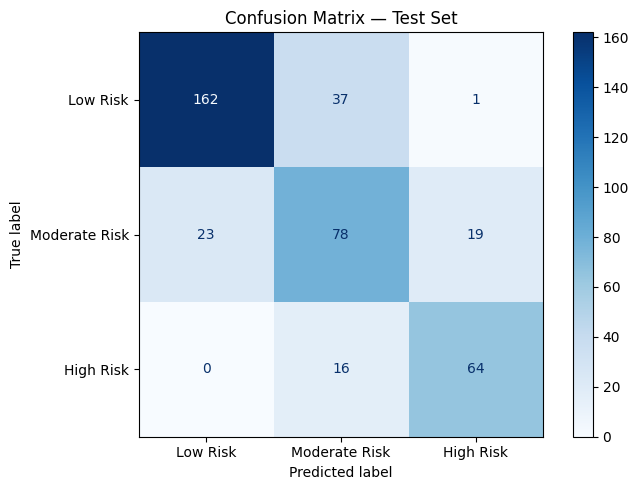

In [56]:
# Step 13 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

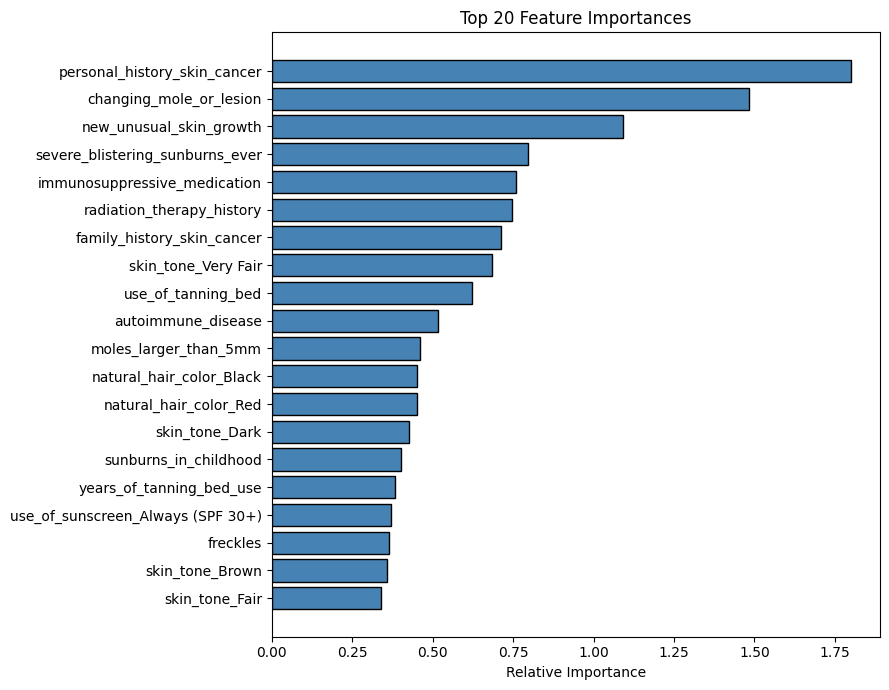

In [62]:
# Updated Step 14
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check if the model has feature_importances_ (Trees) or coef_ (Linear models)
if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=X.columns)
elif hasattr(model, 'coef_'):
    # For Logistic Regression, we use the absolute value of coefficients
    # (using the first class or averaging if multi-class)
    importances = pd.Series(np.abs(model.coef_[0]), index=X.columns)
else:
    print("This model type does not support standard importance attributes.")
    importances = None

if importances is not None:
    top20 = importances.nlargest(20).sort_values()

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top20.index, top20.values, color='steelblue', edgecolor='black')
    ax.set_title('Top 20 Feature Importances')
    ax.set_xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()

In [58]:
# Step 15 — Save the trained model and the column schema
joblib.dump(model,           'skin_cancer_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
joblib.dump(target_map,      'target_map.pkl')

print('Model saved   -> skin_cancer_model.pkl')
print('Columns saved -> feature_columns.pkl')
print('Labels saved  -> target_map.pkl')

Model saved   -> skin_cancer_model.pkl
Columns saved -> feature_columns.pkl
Labels saved  -> target_map.pkl


In [60]:
# Step 16 — Helper: build an encoded row from a raw patient dictionary

def encode_new_patient(patient_dict: dict, feature_columns: list) -> pd.DataFrame:
    """
    Applies the same preprocessing pipeline to a new patient dictionary.
    Returns a single-row DataFrame aligned to the training feature columns.
    """
    row = pd.DataFrame([patient_dict])

    # Ordinal encoding — must match exact strings used in training
    ordinal_encoders = {
        'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
        'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
        'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
        'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
        'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
        'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
        'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
        'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
        'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
        'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
        'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
        'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
        'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
        'protective_clothing_worn':    ['Always', 'Usually', 'Sometimes', 'Rarely', 'Never'],
        'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
        'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
        'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
    }
    for col, cats in ordinal_encoders.items():
        if col in row.columns:
            enc = OrdinalEncoder(categories=[cats], handle_unknown='use_encoded_value', unknown_value=-1)
            row[col] = enc.fit_transform(row[[col]])
            row[col] = row[col].clip(lower=0)

    # Binary Yes/No — only genuine Yes/No fields
    bin_cols = [
        'changing_mole_or_lesion', 'new_unusual_skin_growth',
        'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
        'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history',
    ]
    for col in bin_cols:
        if col in row.columns:
            row[col] = row[col].apply(
                lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
            )

    # One-hot encoding for nominal columns
    nom_cols = ['sex', 'skin_tone', 'natural_hair_color', 'eye_color',
                'use_of_sunscreen', 'smoking_status']
    row = pd.get_dummies(row, columns=nom_cols, drop_first=False)

    # Cast any booleans to float
    bool_cols = row.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        row[bool_cols] = row[bool_cols].astype(float)

    # Align to training schema (add missing dummy cols as 0, drop extra)
    row = row.reindex(columns=feature_columns, fill_value=0).astype(float)

    return row

print('Helper function defined.')

Helper function defined.


In [68]:
# Step 18 — Define a new patient and predict their risk level
# Edit the values below to test different patients.

new_patient = {
    # Demographics
    'age'                            : 45,
    'sex'                            : 'Male',
    'skin_tone'                      : 'Fair',
    'natural_hair_color'             : 'Blonde',
    'eye_color'                      : 'Blue',

    # Physical traits
    'freckles'                       : 'Moderate',          # None / Few / Moderate / Many
    'number_of_moles'                : '26-50',
    'moles_larger_than_5mm'          : '3-5',               # None / 1-2 / 3-5 / More than 5

    # Symptoms
    'changing_mole_or_lesion'        : 'Yes',
    'new_unusual_skin_growth'        : 'No',

    # Sun exposure
    'skin_easily_sunburned'          : 'Often',
    'tanning_ability'                : 'Rarely tans',
    'sunburns_in_childhood'          : '3-5',               # None / 1-2 / 3-5 / More than 5
    'severe_blistering_sunburns_ever': 'Yes',
    'daily_sun_exposure_hours'       : '3-6 hours',
    'outdoor_work_or_recreation'     : 'Daily',             # Rarely / Sometimes / Often / Daily

    # Protection
    'use_of_sunscreen'               : 'Rarely',
    'use_of_tanning_bed'             : 'Never',             # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
    'years_of_tanning_bed_use'       : 'Never used',
    'protective_clothing_worn'       : 'Rarely',            # Always / Usually / Sometimes / Rarely / Never

    # Medical history
    'personal_history_skin_cancer'   : 'No',
    'family_history_skin_cancer'     : 'One relative',      # None / One relative / Two or more relatives
    'immunosuppressive_medication'   : 'No',
    'autoimmune_disease'             : 'No',
    'radiation_therapy_history'      : 'No',

    # Location
    'geographic_location_uv'         : 'High UV region',
    'years_lived_in_high_uv_area'    : '5-15 years',

    # Lifestyle
    'perform_skin_self_checks'       : 'Rarely',            # Monthly / Every few months / Once a year / Rarely / Never
    'seen_dermatologist'             : 'Once every few years', # More than once a year / Annually / Once every few years / Never
    'diet_high_antioxidants'         : 'Rarely',            # Often / Sometimes / Rarely / Never
    'smoking_status'                 : 'Never',
}
feat_cols = list(X.columns)
import joblib

# Load the saved assets from Step 15
loaded_model = joblib.load('skin_cancer_model.pkl')
feat_cols = joblib.load('feature_columns.pkl')
target_map = joblib.load('target_map.pkl')

# Create the inverse map (Numbers -> Text labels)
inv_target_map = {v: k for k, v in target_map.items()}
# Encode and predict
patient_row     = encode_new_patient(new_patient, feat_cols)
predicted_code  = loaded_model.predict(patient_row)[0]
predicted_label = inv_target_map[predicted_code]
proba           = loaded_model.predict_proba(patient_row)[0]

print('=' * 45)
print(f'  Predicted Risk Level : {predicted_label}')
print('=' * 45)
print('\nClass Probabilities:')
for code, label in sorted(inv_target_map.items()):
    print(f'  {label:<18}: {proba[code]*100:.1f}%')

  Predicted Risk Level : Moderate Risk

Class Probabilities:
  Low Risk          : 18.1%
  Moderate Risk     : 68.9%
  High Risk         : 13.0%


In [ ]:
# Step 19 — Batch prediction for multiple new patients

batch_patients = [
    {   # Low-risk profile
        'age': 28, 'sex': 'Female', 'skin_tone': 'Dark', 'natural_hair_color': 'Black',
        'eye_color': 'Brown',
        'freckles': 'None',                        # None / Few / Moderate / Many
        'number_of_moles': '0-10',
        'moles_larger_than_5mm': 'None',           # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'No',
        'new_unusual_skin_growth': 'No',
        'skin_easily_sunburned': 'Never',
        'tanning_ability': 'Tans easily and deeply',
        'sunburns_in_childhood': 'None',           # None / 1-2 / 3-5 / More than 5
        'severe_blistering_sunburns_ever': 'No',
        'daily_sun_exposure_hours': 'Less than 1 hour',
        'outdoor_work_or_recreation': 'Rarely',    # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Always',
        'use_of_tanning_bed': 'Never',             # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'Never used',
        'protective_clothing_worn': 'Usually',     # Always / Usually / Sometimes / Rarely / Never
        'personal_history_skin_cancer': 'No',
        'family_history_skin_cancer': 'None',      # None / One relative / Two or more relatives
        'immunosuppressive_medication': 'No',
        'autoimmune_disease': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'Low UV region',
        'years_lived_in_high_uv_area': 'Never',
        'perform_skin_self_checks': 'Monthly',     # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Annually',          # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Often',         # Often / Sometimes / Rarely / Never
        'smoking_status': 'Never',
    },
    {   # High-risk profile
        'age': 62, 'sex': 'Male', 'skin_tone': 'Very Fair', 'natural_hair_color': 'Red',
        'eye_color': 'Green',
        'freckles': 'Many',                        # None / Few / Moderate / Many
        'number_of_moles': '51-100',
        'moles_larger_than_5mm': 'More than 5',    # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'Yes',
        'skin_easily_sunburned': 'Always',
        'tanning_ability': 'Never tans',
        'sunburns_in_childhood': 'More than 5',
        'severe_blistering_sunburns_ever': 'Yes',
        'daily_sun_exposure_hours': 'More than 6 hours',
        'outdoor_work_or_recreation': 'Daily',     # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Never',
        'use_of_tanning_bed': 'Frequently (weekly)',  # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'More than 5 years',
        'protective_clothing_worn': 'Never',       # Always / Usually / Sometimes / Rarely / Never
        'personal_history_skin_cancer': 'Yes',
        'family_history_skin_cancer': 'Two or more relatives',  # None / One relative / Two or more relatives
        'immunosuppressive_medication': 'Yes',
        'autoimmune_disease': 'No',
        'radiation_therapy_history': 'Yes',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': 'More than 15 years',
        'perform_skin_self_checks': 'Never',       # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Never',             # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Never',         # Often / Sometimes / Rarely / Never
        'smoking_status': 'Current',
    }
]

print(f'Batch predicting {len(batch_patients)} patients...\n')
for i, patient in enumerate(batch_patients, 1):
    row         = encode_new_patient(patient, feat_cols)
    code        = loaded_model.predict(row)[0]
    label       = inv_target_map[code]
    proba_batch = loaded_model.predict_proba(row)[0]
    print(f'Patient {i} (age {patient["age"]}, {patient["sex"]}): {label}')
    for c, l in sorted(inv_target_map.items()):
        print(f'   {l:<18}: {proba_batch[c]*100:.1f}%')
    print()

In [ ]:
# Step 19 — Batch prediction for multiple new patients
# Add as many patient dicts as needed.

batch_patients = [
    {
        'age': 28, 'sex': 'Female', 'skin_tone': 'Dark', 'natural_hair_color': 'Black',
        'eye_color': 'Brown',
        'freckles': 'None',                        # None / Few / Moderate / Many
        'number_of_moles': '0-10',
        'moles_larger_than_5mm': 'None',           # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'No',
        'new_unusual_skin_growth': 'No',
        'skin_easily_sunburned': 'Never',
        'tanning_ability': 'Tans easily and deeply',
        'sunburns_in_childhood': 'None',           # None / 1-2 / 3-5 / More than 5
        'severe_blistering_sunburns_ever': 'No',
        'daily_sun_exposure_hours': 'Less than 1 hour',
        'outdoor_work_or_recreation': 'Rarely',    # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Always',
        'use_of_tanning_bed': 'Never',             # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'Never used',
        'protective_clothing_worn': 'Usually',     # Always / Usually / Sometimes / Rarely / Never
        'personal_history_skin_cancer': 'No',
        'family_history_skin_cancer': 'None',      # None / One relative / Two or more relatives
        'immunosuppressive_medication': 'No',
        'autoimmune_disease': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'Low UV region',
        'years_lived_in_high_uv_area': 'Never',
        'perform_skin_self_checks': 'Monthly',     # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Annually',          # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Often',         # Often / Sometimes / Rarely / Never
        'smoking_status': 'Never',
    },
    {
        'age': 62, 'sex': 'Male', 'skin_tone': 'Very Fair', 'natural_hair_color': 'Red',
        'eye_color': 'Green',
        'freckles': 'Many',                        # None / Few / Moderate / Many
        'number_of_moles': '51-100',
        'moles_larger_than_5mm': 'More than 5',    # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'Yes',
        'skin_easily_sunburned': 'Always',
        'tanning_ability': 'Never tans',
        'sunburns_in_childhood': 'More than 5',
        'severe_blistering_sunburns_ever': 'Yes',
        'daily_sun_exposure_hours': 'More than 6 hours',
        'outdoor_work_or_recreation': 'Daily',     # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Never',
        'use_of_tanning_bed': 'Frequently (weekly)',  # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'More than 5 years',
        'protective_clothing_worn': 'Never',       # Always / Usually / Sometimes / Rarely / Never
        'personal_history_skin_cancer': 'Yes',
        'family_history_skin_cancer': 'Two or more relatives',  # None / One relative / Two or more relatives
        'immunosuppressive_medication': 'Yes',
        'autoimmune_disease': 'No',
        'radiation_therapy_history': 'Yes',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': 'More than 15 years',
        'perform_skin_self_checks': 'Never',       # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Never',             # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Never',         # Often / Sometimes / Rarely / Never
        'smoking_status': 'Current',
    }
]

print(f'Batch predicting {len(batch_patients)} patients...\n')
for i, patient in enumerate(batch_patients, 1):
    row   = encode_new_patient(patient, feat_cols)
    code  = loaded_model.predict(row)[0]
    label = inv_target_map[code]
    proba_batch = loaded_model.predict_proba(row)[0]
    print(f'Patient {i} (age {patient["age"]}, {patient["sex"]}): {label}')
    for c, l in sorted(inv_target_map.items()):
        print(f'   {l:<18}: {proba_batch[c]*100:.1f}%')
    print()